## Supervised Fine-tuning of LLM Visualization


In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import os

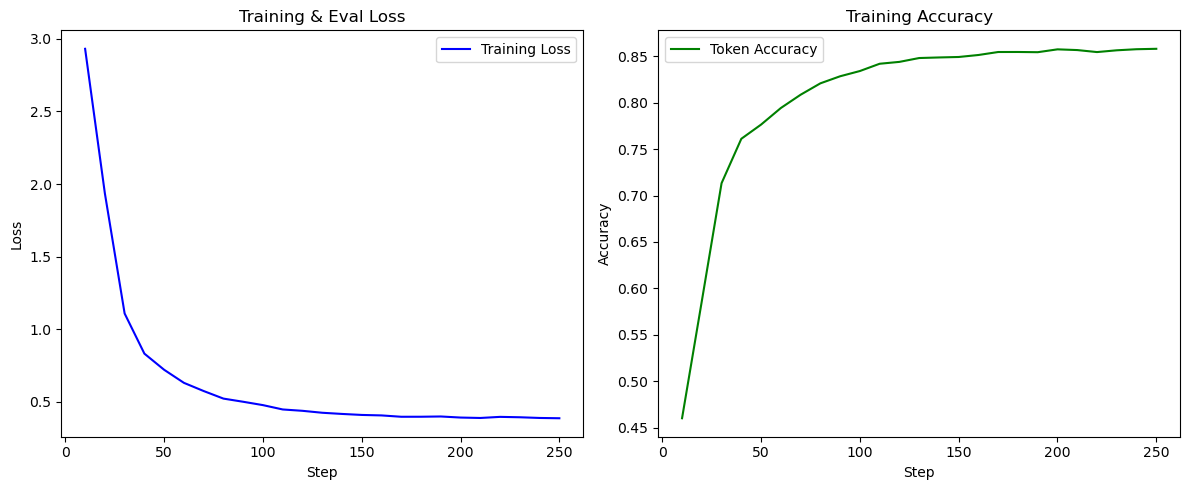

In [7]:
root_dir = "./qwen-yoga-finetune"
checkpoint_dir = "checkpoint-258"
file_name = Path(os.path.join(root_dir, checkpoint_dir, 'trainer_state.json')).resolve()
# 1. Load the trainer_state.json
with open(file_name, 'r') as f:
    data = json.load(f)

# 2. Extract log_history into a DataFrame
df = pd.DataFrame(data['log_history'])

# 3. Separate Training and Evaluation logs
# Training logs usually have 'loss'
train_df = df[df['loss'].notna()]
# Evaluation logs usually have 'eval_loss' or 'eval_accuracy'
try:
    eval_df = df[df['eval_loss'].notna()]
except:
    eval_df = pd.DataFrame()
# 4. Plotting
plt.figure(figsize=(12, 5))

# Plot 1: Loss Curves
plt.subplot(1, 2, 1)
plt.plot(train_df['step'], train_df['loss'], label='Training Loss', color='blue')
if not eval_df.empty:
    plt.plot(eval_df['step'], eval_df['eval_loss'], label='Eval Loss', color='red', linestyle='--')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.title('Training & Eval Loss')
plt.legend()

# Plot 2: Accuracy (if available)
plt.subplot(1, 2, 2)
if 'mean_token_accuracy' in train_df.columns:
    plt.plot(train_df['step'], train_df['mean_token_accuracy'], label='Token Accuracy', color='green')
plt.xlabel('Step')
plt.ylabel('Accuracy')
plt.title('Training Accuracy')
plt.legend()

plt.tight_layout()
plt.show()
